# 示例策略4: 多因子选股策略

本策略每隔1个月定时触发,根据Fama-French三因子模型对每只股票进行回归，得到其alpha值。
假设Fama-French三因子模型可以完全解释市场，则alpha为负表明市场低估该股，因此应该买入。

策略思路：

计算市场收益率、个股的账面市值比和市值,并对后两个进行了分类,
根据分类得到的组合分别计算其市值加权收益率、SMB和HML. 
对各个股票进行回归(假设无风险收益率等于0)得到alpha值.

选取alpha值小于0并为最小的10只股票进入标的池，平掉不在标的池的股票并等权买入在标的池的股票

回测数据:SHSE.000300的成份股

回测时间为:2016-04-05 到 2021-02-01

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../..'))
# 导入qteasy模块
import qteasy as qt
print(f'qteasy version: {qt.__version__}, datasource: {qt.QT_DATA_SOURCE}')

qteasy version: 2.2.1, datasource: mysql://www.qteasy.cn@9306/ts_db


In [2]:
qt.find_history_data('total_mv') 
# found 'pb', and 'total_mv' for asset E
# qt.get_history_data('total_mv', shares='000300.SH, 000001.SZ, 000451.SZ', asset_type='E,IDX')
qt.find_history_data('pb')

matched following history data, 
use "qt.get_history_data()" to load these historical data by its data_id:
------------------------------------------------------------------------
              name freq asset            table    column               desc
data_id                                                                    
total_mv  total_mv    d   IDX  index_indicator  total_mv  指数技术指标 - 当日总市值（元）
total_mv  total_mv    d     E  stock_indicator  total_mv  股票技术指标 - 总市值 （万元）
matched following history data, 
use "qt.get_history_data()" to load these historical data by its data_id:
------------------------------------------------------------------------
        name freq asset            table column                   desc
data_id                                                               
pb        pb    d   IDX  index_indicator     pb           指数技术指标 - 市净率
pb        pb    d     E  stock_indicator     pb  股票技术指标 - 市净率（总市值/净资产）


['pb', 'pb']

In [10]:
from qteasy import Parameter, StgData
import numpy as np
def market_value_weighted(stock_return, mv, mv_cat, bp_cat, mv_target, bp_target):
    """ 根据mv_target和bp_target计算市值加权收益率

    """
    sel = (mv_cat == mv_target) & (bp_cat == bp_target)
    mv_total = np.nansum(mv[sel])
    mv_weight = mv / mv_total
    return_total = np.nansum(stock_return[sel] * mv_weight[sel])
    return return_total


class MultiFactors(qt.FactorSorter):
    
    def __init__(self, pars: tuple = (0.5, 0.3, 0.7)):
        super().__init__(
                name='MultiFactor',
                description='根据Fama-French三因子回归模型估算HS300成分股的alpha值选股',
                pars=[Parameter((0.01, 0.99), par_type='float', name='size_gate', value=0.5),  # 参数1:大小市值分类界限
                      Parameter((0.01, 0.49), par_type='float', name='pb_s', value=0.3),  # 参数2:小/中bp分界线
                      Parameter((0.50, 0.99), par_type='float', name='pb_l', value=0.7)],  # 参数3，中/大bp分界线
                data_types=[StgData('pb', freq='d', asset_type='E', window_length=20, use_latest_data_cycle=True), 
                            StgData('total_mv', freq='d', asset_type='E', window_length=2, use_latest_data_cycle=True), 
                            StgData('close', freq='d', asset_type='E', window_length=20, use_latest_data_cycle=True),
                            StgData('close-000300.SH', freq='d', asset_type='IDX', window_length=20, use_latest_data_cycle=True)],  # 执行选股需要用到的股票数据
                max_sel_count=10,  # 最多选出10支股票
                sort_ascending=True,  # 选择因子最小的股票
                condition='less',  # 仅选择因子小于某个值的股票
                lbound=0,  # 仅选择因子小于0的股票
                ubound=0,  # 仅选择因子小于0的股票
        )
    
    def realize(self):

        size_gate_percentile, bp_small_percentile, bp_large_percentile = self.get_pars('size_gate', 'pb_s', 'pb_l')
        # 读取投资组合的数据PB和total_MV的最新值
        pb, mv, closes, market_closes = self.get_data('pb_E_d', 'total_mv_E_d', 'close_E_d', 'close-000300.SH_IDX_d')
        pb = pb[-1]  # 当前所有股票的PB值
        mv = mv[-1]  # 当前所有股票的市值
        pre_close = closes[-2]  # 当前所有股票的前收盘价
        close = closes[-1]  # 当前所有股票的最新收盘价

        # 读取参考数据(r)
        market_pre_close = market_closes[-2]  # HS300的昨收价
        market_close = market_closes[-1]  # HS300的收盘价
        # import pdb; pdb.set_trace()

        # 计算账面市值比，为pb的倒数
        bp = pb ** -1
        # 计算市值的50%的分位点,用于后面的分类
        size_gate = np.nanquantile(mv, size_gate_percentile)
        # 计算账面市值比的30%和70%分位点,用于后面的分类
        bm_30_gate = np.nanquantile(bp, bp_small_percentile)
        bm_70_gate = np.nanquantile(bp, bp_large_percentile)
        # 计算每只股票的当日收益率
        stock_return = pre_close / close - 1

        # 根据每只股票的账面市值比和市值，给它们分配bp分类和mv分类
        # 市值小于size_gate的cat为1，否则为2
        mv_cat = np.ones_like(mv)
        mv_cat += (mv > size_gate).astype('float')
        # bp小于30%的cat为1，30%～70%之间为2，大于70%为3
        bp_cat = np.ones_like(bp)
        bp_cat += (bp > bm_30_gate).astype('float')
        bp_cat += (bp > bm_70_gate).astype('float')

        # 获取小市值组合的市值加权组合收益率
        smb_s = (market_value_weighted(stock_return, mv, mv_cat, bp_cat, 1, 1) +
                 market_value_weighted(stock_return, mv, mv_cat, bp_cat, 1, 2) +
                 market_value_weighted(stock_return, mv, mv_cat, bp_cat, 1, 3)) / 3
        # 获取大市值组合的市值加权组合收益率
        smb_b = (market_value_weighted(stock_return, mv, mv_cat, bp_cat, 2, 1) +
                 market_value_weighted(stock_return, mv, mv_cat, bp_cat, 2, 2) +
                 market_value_weighted(stock_return, mv, mv_cat, bp_cat, 2, 3)) / 3
        smb = smb_s - smb_b
        # 获取大账面市值比组合的市值加权组合收益率
        hml_b = (market_value_weighted(stock_return, mv, mv_cat, bp_cat, 1, 3) +
                 market_value_weighted(stock_return, mv, mv_cat, bp_cat, 2, 3)) / 2
        # 获取小账面市值比组合的市值加权组合收益率
        hml_s = (market_value_weighted(stock_return, mv, mv_cat, bp_cat, 1, 1) +
                 market_value_weighted(stock_return, mv, mv_cat, bp_cat, 2, 1)) / 2
        hml = hml_b - hml_s

        # 计算市场收益率
        market_return = market_pre_close / market_close - 1

        coff_pool = []
        # 对每只股票进行回归获取其alpha值
        for rtn in stock_return:
            x = np.array([[market_return, smb, hml, 1.0]])
            y = np.array([[rtn]])
            # OLS估计系数
            coff = np.linalg.lstsq(x, y)[0][3][0]
            coff_pool.append(coff)

        # 以alpha值为股票组合的选股因子执行选股
        factors = np.array(coff_pool)

        return factors

474 ['000001.SZ', '000002.SZ', '000063.SZ', '000069.SZ', '000100.SZ', '000157.SZ', '000166.SZ', '000333.SZ', '000338.SZ', '000413.SZ']


/var/folders/y3/dkxn4vrn20n2ntx6y_v8vlym0000gn/T/ipykernel_19220/2006366207.py:94: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coff = np.linalg.lstsq(x, y)[0][3][0]



|                                  |
|         BACKTEST REPORT          |
|                                  |
qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 205.4 ms
time consumption for operation back testing:  549.2 ms
investment starts on      2016-04-05 15:00:00
ends on                   2021-01-29 15:00:00
Total looped periods:     4.8 years.
-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary
          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000002.SZ    2        2      4     3.6%     -0.0%     96.4%  
000100.SZ    1        1      2     1.9%     -0.0%     98.1%  
000333.SZ    1        1      2     3.5%     -0.0%     96.5%  
000338.SZ    1        2      3     1.4%     -0.0%     98.6%  
000413.SZ    2        2      4     3.4%     -0.0%     96.6%  
000423.SZ    1        1      2     2.0%     -0.0%     98.0%  
000568.SZ    1        1

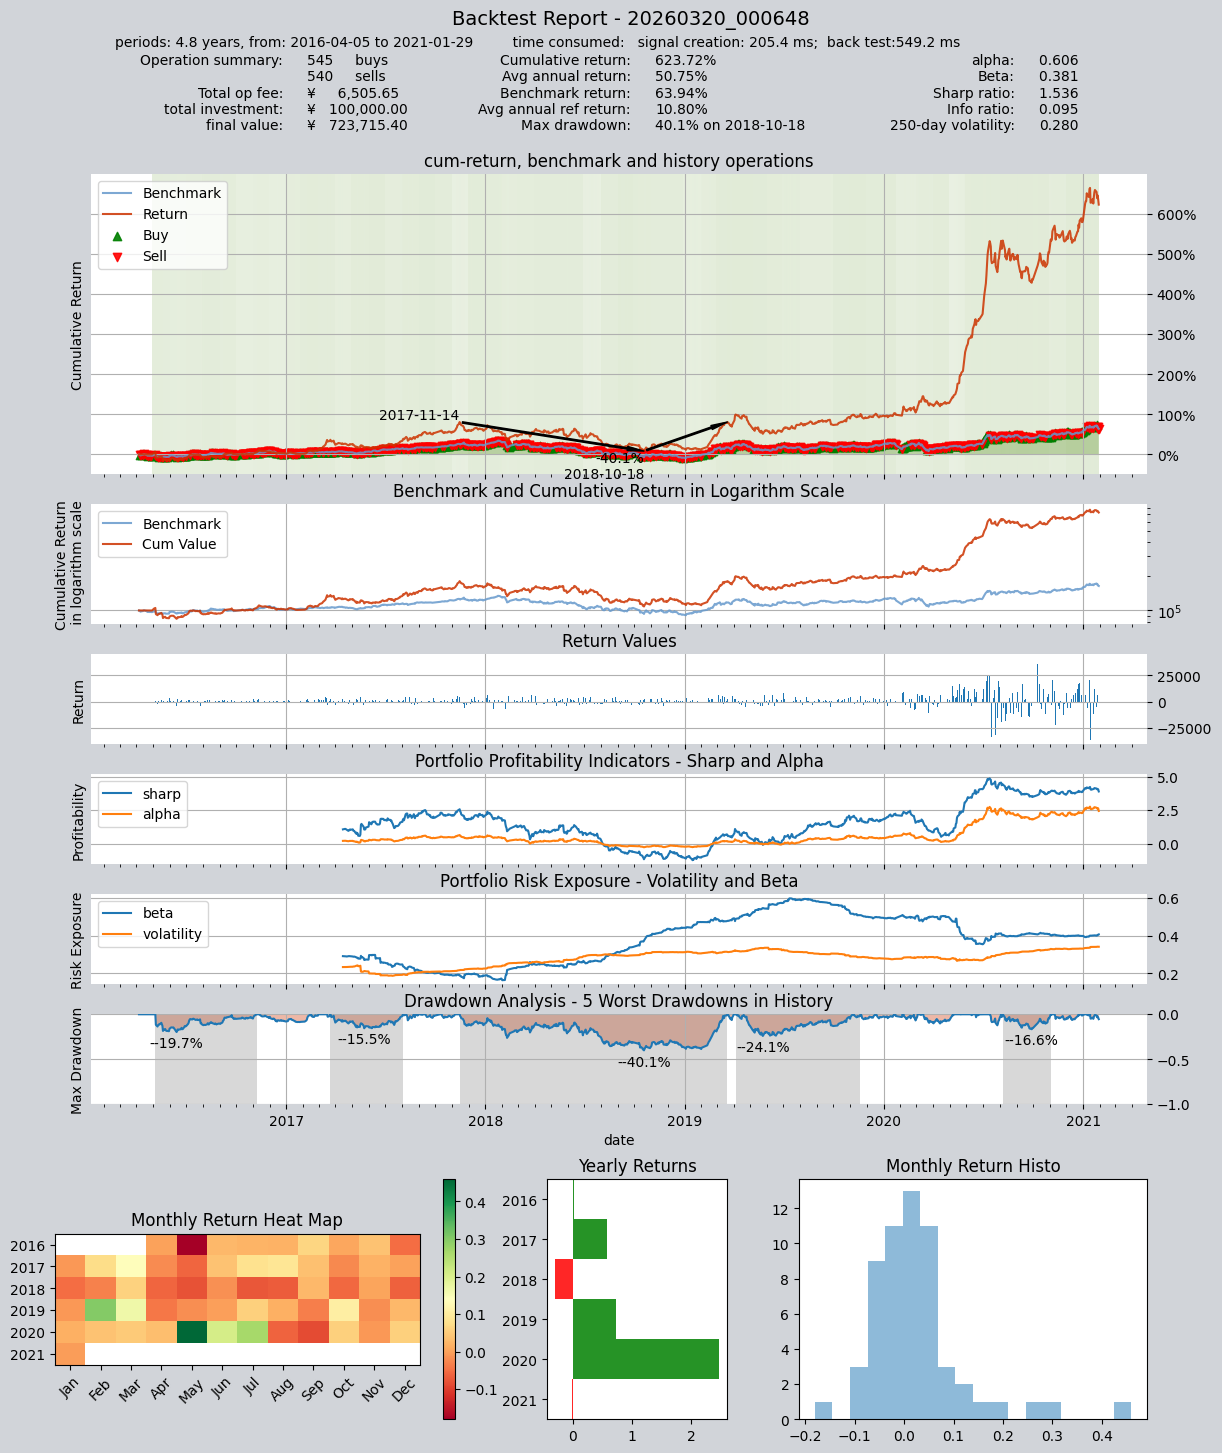

In [11]:
shares = qt.filter_stock_codes(index='000300.SH', date='20190501')
print(len(shares), shares[:10])
alpha = MultiFactors()
op = qt.Operator(alpha, signal_type='PT', run_freq='ME')
qt.run(op=op,
       mode=1,
       invest_start='20160405',
       invest_end='20210201',
       asset_type='E',
       asset_pool=shares,
       trade_batch_size=100,
       sell_batch_size=1,
       trade_log=True,
      )

print()